In [2]:
import os
import pandas as pd
import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

In [3]:
BASE_PATH = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign'

# Create the Dataset 
1. Create the Dataset Class for loading the kaggle dataset images
2. Define transformations for train and val/test splits
3. Add augmentations in transformation enhanced training data.
4. Split the dataset by indices, and stratify each class to 

### Define Dataset Class

In [4]:
class GTSRBDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        """
        Args:
            dataframe (pandas.DataFrame): DataFrame containing 'Path' and 'ClassId'.
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.dataframe = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform
        
        self.image_paths = self.dataframe['Path'].values
        self.labels = self.dataframe['ClassId'].values
        self.classes = sorted(self.dataframe['ClassId'].unique())

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # The 'Path' column in the CSV already includes 'Train/...' or 'Test/...'
        img_path = os.path.join(self.root_dir, self.image_paths[idx])
        
        # Convert to RGB to ensure 3 channels (required for AlexNet)
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

### Image Transforms

In [5]:
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                 std=[0.229, 0.224, 0.225])

# Updated Transforms for Traffic Signs
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),           # Resize to uniform $256 \times 256$
    transforms.RandomCrop(224),              # Crop to $224 \times 224$ for AlexNet
    transforms.RandomRotation(15),           # Keep slight rotations
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Better for outdoor lighting variation
    transforms.ToTensor(),
    normalize
])

test_transforms = transforms.Compose([    
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),              # Center crop for validation/testing
    transforms.ToTensor(),
    normalize
])

### Load and Split Data

In [6]:
# Load CSVs
train_csv_path = os.path.join(BASE_PATH, 'Train.csv')
test_csv_path = os.path.join(BASE_PATH, 'Test.csv')

train_df_raw = pd.read_csv(train_csv_path)
test_df_raw = pd.read_csv(test_csv_path)

# Combine both datasets to create a single pool for a strict 70/15/15 split
full_df = pd.concat([train_df_raw, test_df_raw], ignore_index=True)

# Split 1: 70% Training, 30% Temp (which will become Val and Test)
train_df, temp_df = train_test_split(full_df, test_size=0.30, random_state=42, stratify=full_df['ClassId'])

# Split 2: Divide the 30% Temp evenly to get 15% Validation and 15% Testing
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['ClassId'])

# --- Create Dataset Objects ---
train_dataset = GTSRBDataset(train_df, BASE_PATH, transform=train_transforms)
val_dataset = GTSRBDataset(val_df, BASE_PATH, transform=test_transforms)
test_dataset = GTSRBDataset(test_df, BASE_PATH, transform=test_transforms)

# --- Create DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

num_classes = len(train_dataset.classes)
print(f"Total classes: {num_classes}")
print(f"Training samples: {len(train_dataset)} | Validation samples: {len(val_dataset)} | Testing samples: {len(test_dataset)}")

Total classes: 43
Training samples: 36287 | Validation samples: 7776 | Testing samples: 7776


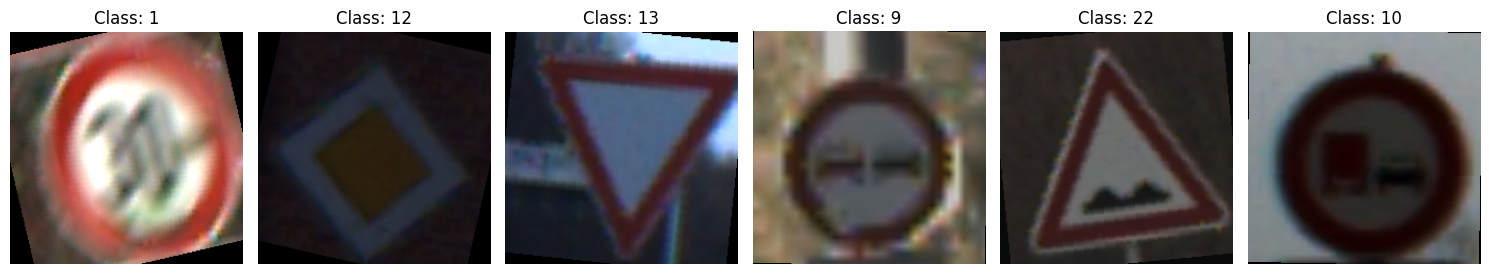

In [7]:
def imshow_batch(images, labels, num_images=6):
    """
    Un-normalizes and displays a batch of images to verify augmentations.
    """
    # Inverse normalization parameters
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    
    for i in range(num_images):
        # Convert tensor to numpy and permute dimensions (C, H, W) -> (H, W, C)
        img = images[i].numpy().transpose((1, 2, 0))
        
        # Un-normalize to get image back to [0, 1] range for viewing
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        axes[i].imshow(img)
        axes[i].set_title(f"Class: {labels[i].item()}")
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

# Fetch one batch of training data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show the first 6 images from the batch
imshow_batch(images, labels, num_images=6)

/tmp/ipykernel_58/3574179339.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


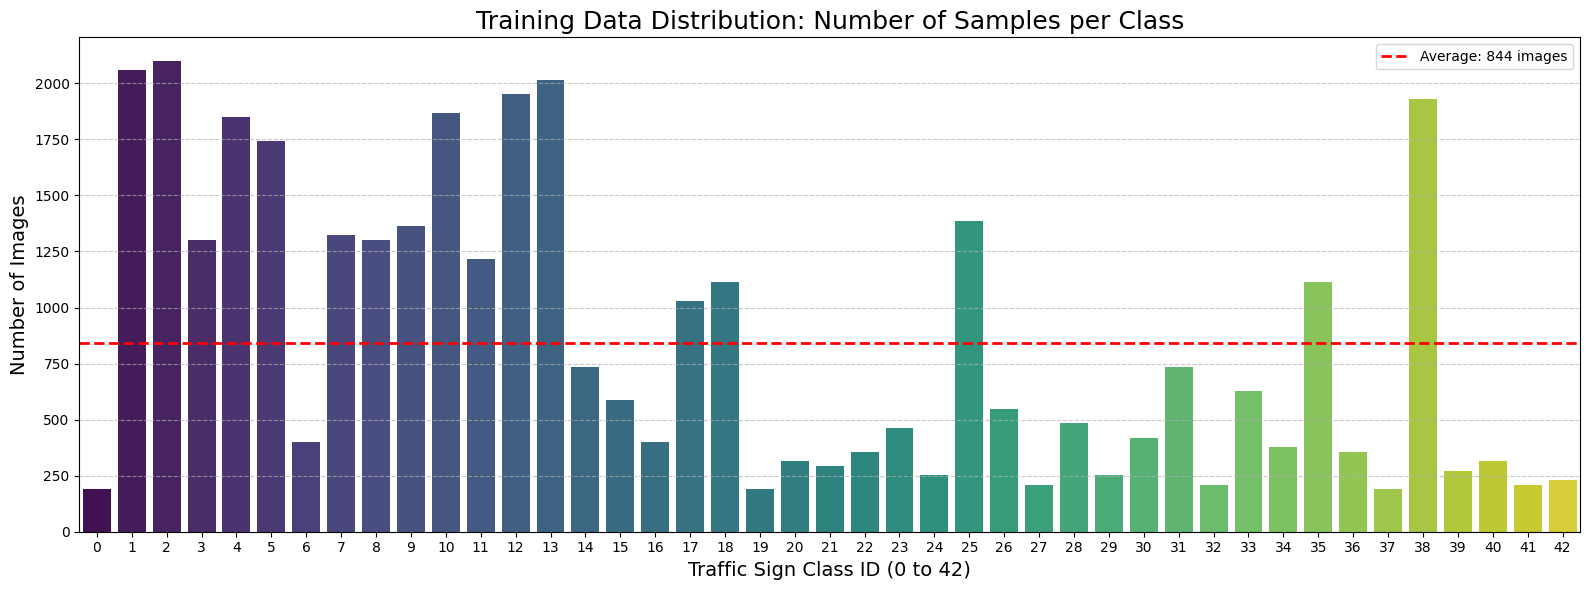

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each ClassId in the training dataframe
class_counts = train_df['ClassId'].value_counts().sort_index()

plt.figure(figsize=(16, 6))
# Create a bar plot using a nice color gradient
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")

plt.title('Training Data Distribution: Number of Samples per Class', fontsize=18)
plt.xlabel('Traffic Sign Class ID (0 to 42)', fontsize=14)
plt.ylabel('Number of Images', fontsize=14)

# Add a horizontal line showing the average number of images per class
average_samples = class_counts.mean()
plt.axhline(average_samples, color='red', linestyle='--', linewidth=2, label=f'Average: {average_samples:.0f} images')
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

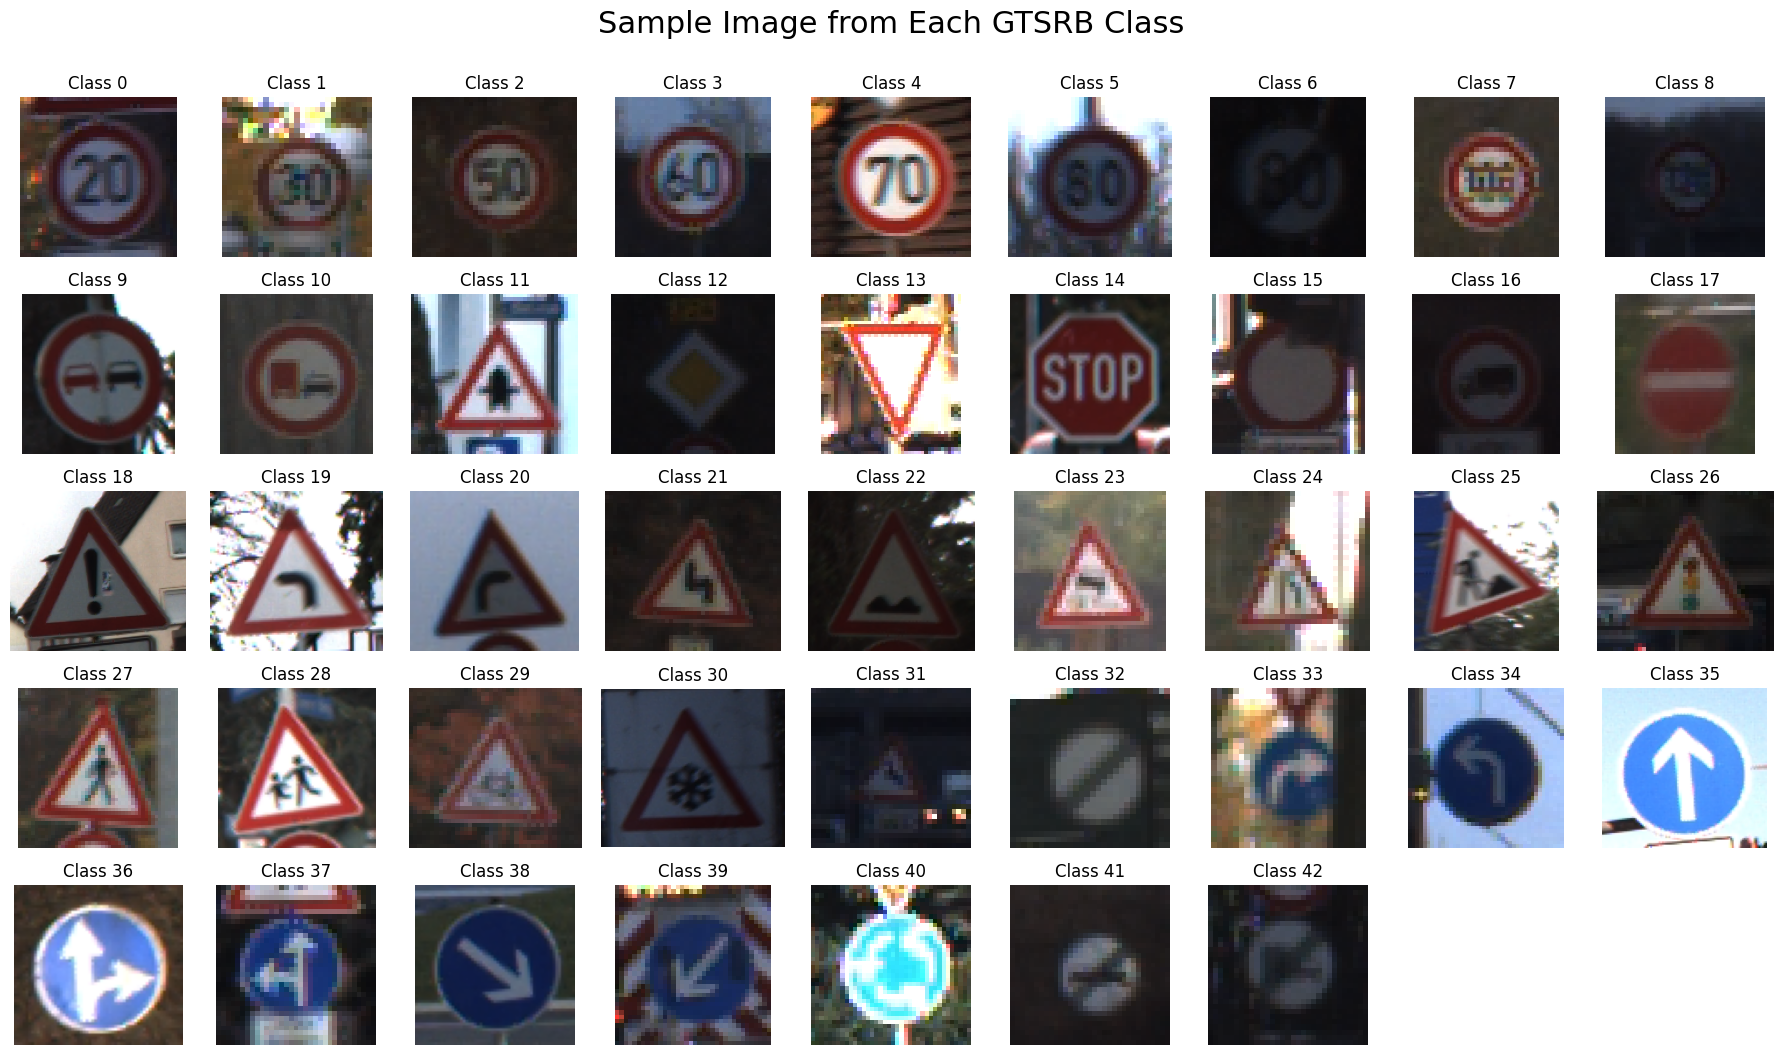

In [10]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Set up a grid of 5 rows and 9 columns (45 spots total for our 43 classes)
fig, axes = plt.subplots(5, 9, figsize=(18, 10))
axes = axes.ravel() # Flatten the grid array for easy iteration

# Loop through all 43 classes
for i in range(45):
    if i < 43:
        # Filter the dataframe to only the current class and grab the very first row
        sample_row = train_df[train_df['ClassId'] == i].iloc[0]
        
        # Construct the full image path
        img_path = os.path.join(BASE_PATH, sample_row['Path'])
        
        # Open the raw, un-augmented image
        img = Image.open(img_path)
        
        axes[i].imshow(img)
        axes[i].set_title(f"Class {i}", fontsize=12)
        axes[i].axis('off') # Hide the axis lines
    else:
        # Hide the 2 extra empty subplots at the end of the grid (44 and 45)
        axes[i].axis('off') 

plt.tight_layout()
plt.suptitle("Sample Image from Each GTSRB Class", fontsize=22, y=1.05)
plt.show()

# Module Setup & Transfer Learning

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import copy
import time
from tqdm import tqdm 

# --- 1. Model Setup & Transfer Learning ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# Load pre-trained AlexNet
model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)

# Fine-tuning Strategy: Freeze the feature extraction layers
for param in model.features.parameters():
    param.requires_grad = False

# Modify the classifier head for GTSRB (43 classes, not 42)
num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_ftrs, num_classes) 
model = model.to(device)

# Deliverable: Model Summary
print("\n--- Model Architecture Summary ---")
print(model)

Training on device: cuda

--- Model Architecture Summary ---
AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    

### Hyperparameters

In [22]:
# --- 2. Hyperparameters ---
num_epochs = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.0001)

patience = 3                 # How many epochs to wait before stopping
epochs_no_improve = 0        # Counter for epochs without improvement

In [23]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []

# Training Loop
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
best_val_loss = np.inf       # Track the lowest validation loss
early_stop = False           # Flag to break the outer loop

print(f"\n--- Starting Training (Patience: {patience}) ---")
start_time = time.time()

for epoch in range(num_epochs):
    if early_stop:
        break

    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 10)

    # Each epoch has a training and validation phase
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()  # Set model to training mode
            dataloader = train_loader
            dataset_size = len(train_dataset)
        else:
            model.eval()   # Set model to evaluate mode
            dataloader = val_loader
            dataset_size = len(val_dataset)

        running_loss = 0.0
        running_corrects = 0

        # Wrap the dataloader in tqdm
        progress_bar = tqdm(dataloader, desc=f'{phase.capitalize()} Phase', leave=False)

        # Iterate over data using the progress bar
        for inputs, labels in progress_bar:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                # Backward pass and optimize only if in training phase
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            # Statistics
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
            # Update the progress bar with the current batch loss
            progress_bar.set_postfix({'batch_loss': f'{loss.item():.4f}'})

        # Calculate epoch statistics
        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.double() / dataset_size
        
        # Save the metrics to our lists
        if phase == 'train':
            train_losses.append(epoch_loss)
            train_accs.append(epoch_acc.item())
        else:
            val_losses.append(epoch_loss)
            val_accs.append(epoch_acc.item())

        print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # --- Early Stopping & Model Saving Logic (Validation Phase) ---
        if phase == 'val':
            # 1. Check for best accuracy to save model weights
            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
            
            # 2. Check for validation loss improvement for Early Stopping
            if epoch_loss < best_val_loss:
                best_val_loss = epoch_loss
                epochs_no_improve = 0  # Reset counter
            else:
                epochs_no_improve += 1
                print(f"⚠️ Early stopping counter: {epochs_no_improve} out of {patience}")
                
                if epochs_no_improve >= patience:
                    print("🛑 Early stopping triggered! Validation loss hasn't improved.")
                    early_stop = True
                    break # Break the phase loop

    print()

time_elapsed = time.time() - start_time
print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
print(f'Best Validation Accuracy: {best_acc:.4f}')

# --- 4. Save the Model ---
model.load_state_dict(best_model_wts)

save_path = 'alexnet_gtsrb_finetuned.pth'
torch.save(model.state_dict(), save_path)
print(f"Model successfully saved to {save_path}")


--- Starting Training (Patience: 3) ---
Epoch 1/15
----------


Train Loss: 0.8950 Acc: 0.7195


Val Loss: 0.2851 Acc: 0.8998

Epoch 2/15
----------


Train Loss: 0.3726 Acc: 0.8738


Val Loss: 0.1219 Acc: 0.9626

Epoch 3/15
----------


...

Val Loss: 0.0385 Acc: 0.9884

Epoch 14/15
----------


Train Loss: 0.1209 Acc: 0.9588


Val Loss: 0.0372 Acc: 0.9875

Epoch 15/15
----------


Train Loss: 0.1263 Acc: 0.9582


Val Loss: 0.0311 Acc: 0.9906

Training complete in 28m 51s
Best Validation Accuracy: 0.9906
Model successfully saved to alexnet_gtsrb_finetuned.pth


# Evaluation

In [33]:
import torch
import torch.nn.functional as F

# Ensure the model is in evaluation mode
model.eval()

all_preds = []
all_labels = []
all_probs = [] 

print("Evaluating model on the test dataset...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        
        # Get the predicted class index
        _, preds = torch.max(outputs, 1)
            
        probs = F.softmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())  # Save probabilities

Evaluating model on the test dataset...


### Classification Metrics

In [30]:
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
accuracy = accuracy_score(all_labels, all_preds)

print("\n--- Performance Metrics Table (Test Set) ---")
metrics_data = {
    "Metric": ["Accuracy", "Precision (Macro)", "Recall (Macro)", "F1-Score (Macro)"],
    "Score": [f"{accuracy * 100:.2f}%", f"{precision:.4f}", f"{recall:.4f}", f"{f1:.4f}"]
}
metrics_df = pd.DataFrame(metrics_data)
print(metrics_df.to_string(index=False))


--- Performance Metrics Table (Test Set) ---
           Metric  Score
         Accuracy 98.91%
Precision (Macro) 0.9924
   Recall (Macro) 0.9899
 F1-Score (Macro) 0.9910


# Per-Epoch Loss and Accuracy

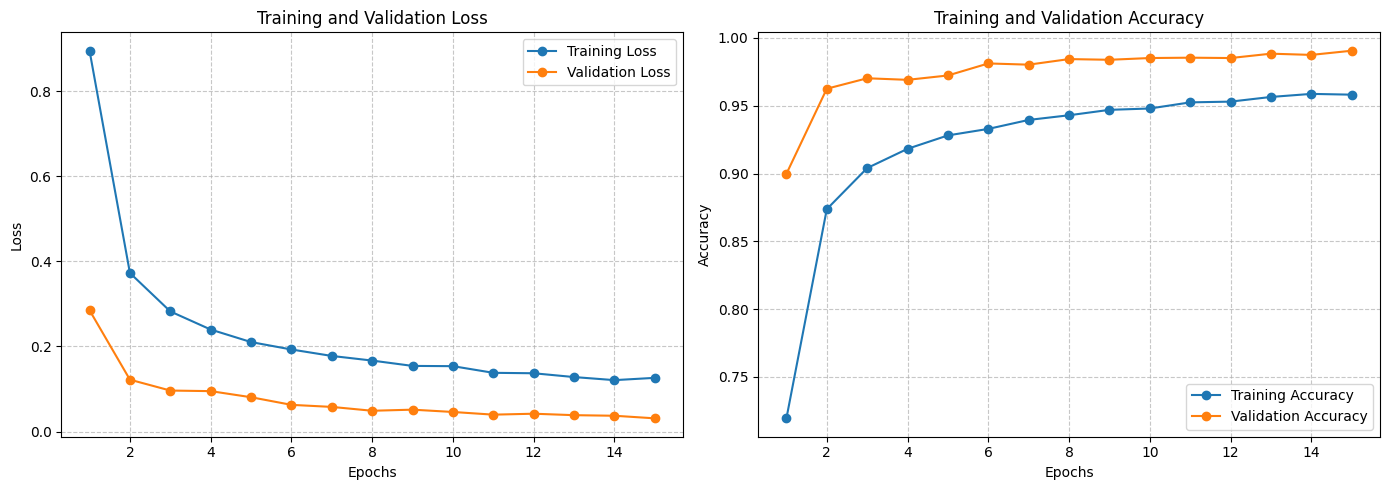

In [29]:
import matplotlib.pyplot as plt

def plot_training_history(train_losses, val_losses, train_accs, val_accs):
    # Create an array of epoch numbers for the x-axis
    epochs = range(1, len(train_losses) + 1)
    
    # Set up a figure with two subplots side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- 1. Plot Loss ---
    ax1.plot(epochs, train_losses, label='Training Loss', marker='o')
    ax1.plot(epochs, val_losses, label='Validation Loss', marker='o')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # --- 2. Plot Accuracy ---
    ax2.plot(epochs, train_accs, label='Training Accuracy', marker='o')
    ax2.plot(epochs, val_accs, label='Validation Accuracy', marker='o')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    # Display the plots
    plt.tight_layout()
    plt.show()

# Call the function using the lists from your training loop
plot_training_history(train_losses, val_losses, train_accs, val_accs)

## Confusion Matrix

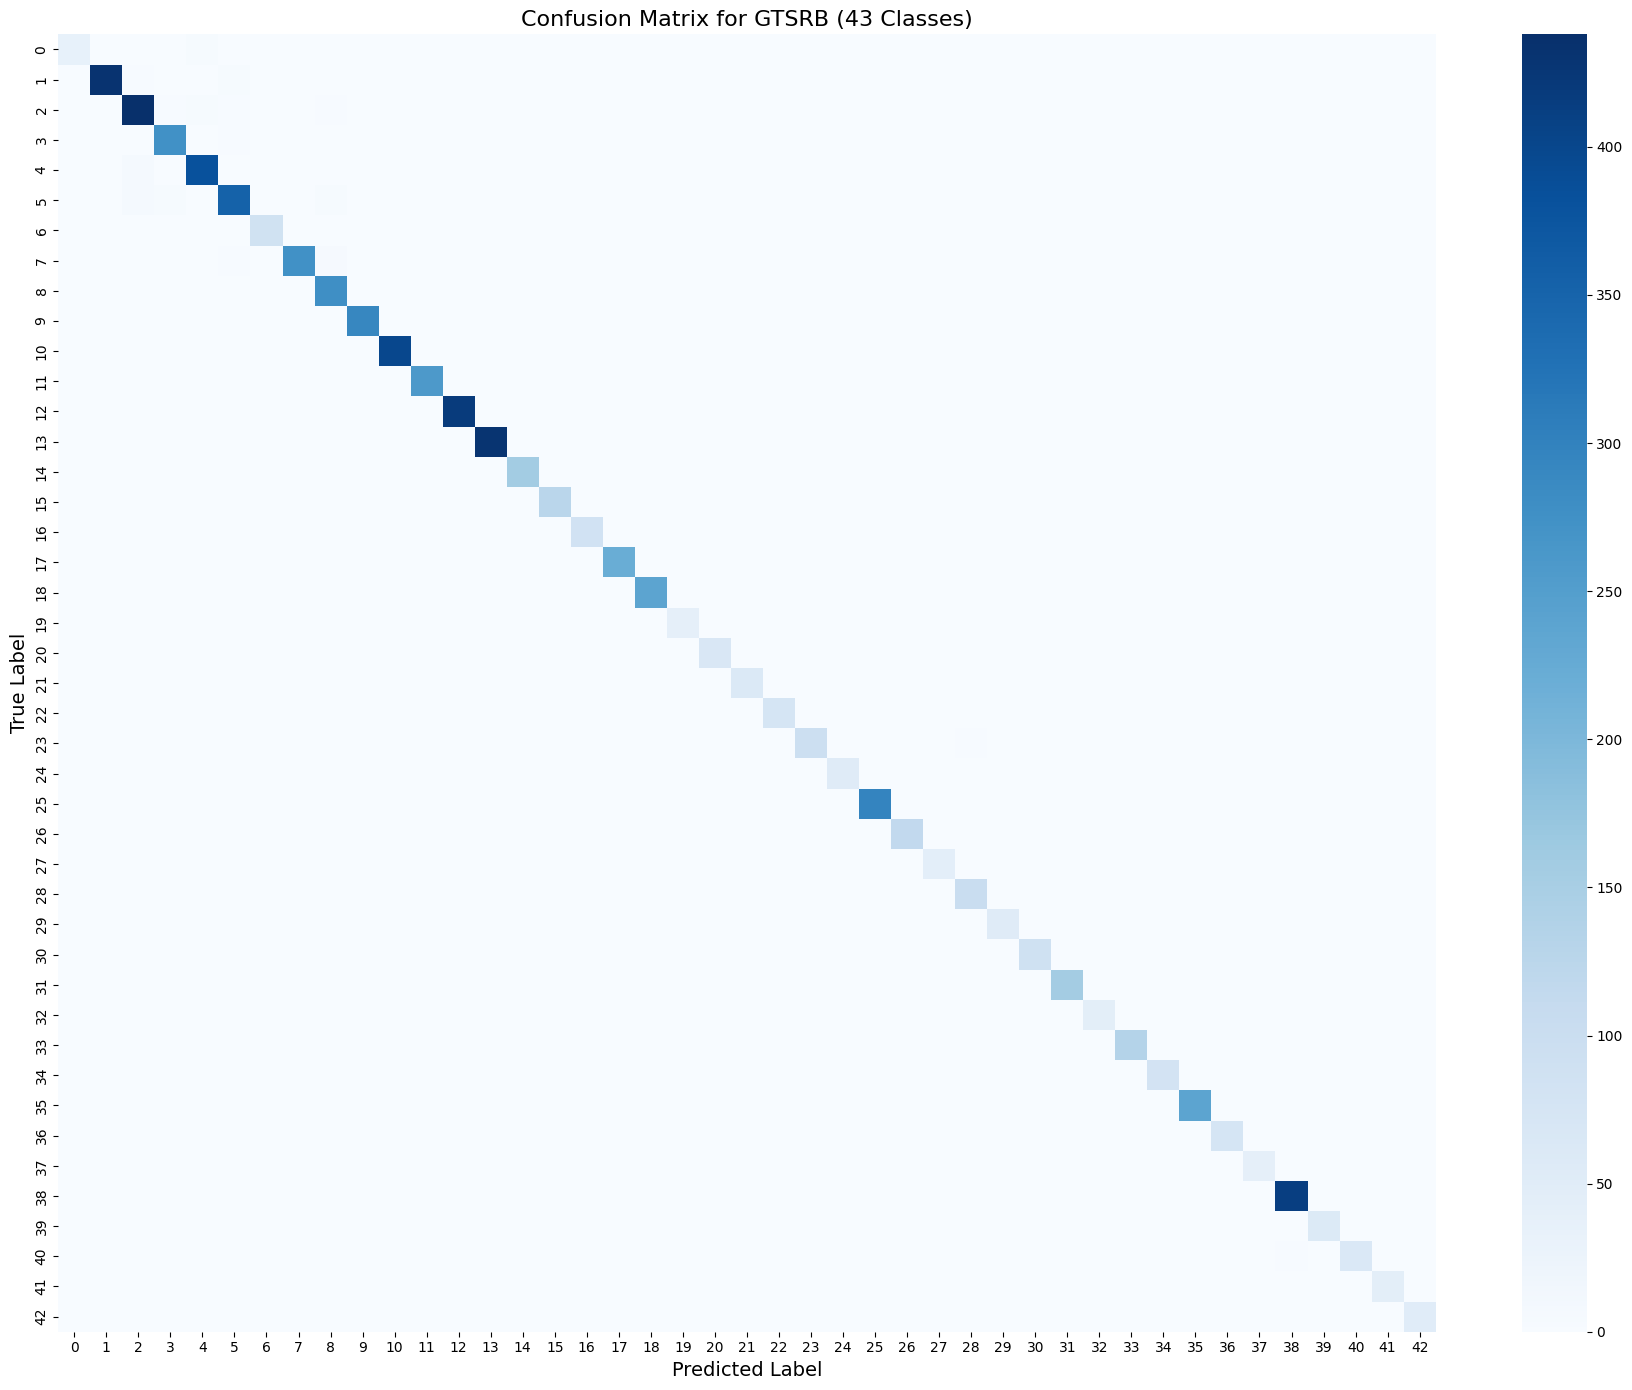

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(true_labels, predicted_labels, num_classes=43):
    # Calculate the raw confusion matrix
    cm = confusion_matrix(true_labels, predicted_labels)

    # Set up the matplotlib figure
    plt.figure(figsize=(18, 14))
    
    # Create a heatmap using seaborn
    # cmap='Blues' gives it a nice color gradient where darker = higher numbers
    sns.heatmap(cm, annot=False, cmap='Blues', cbar=True)
    
    plt.title('Confusion Matrix for GTSRB (43 Classes)', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    
    plt.tight_layout()
    plt.show()

# Call the function
plot_confusion_matrix(all_labels, all_preds)

## ROC AUC CURVE

Macro-Average ROC AUC Score: 1.0000


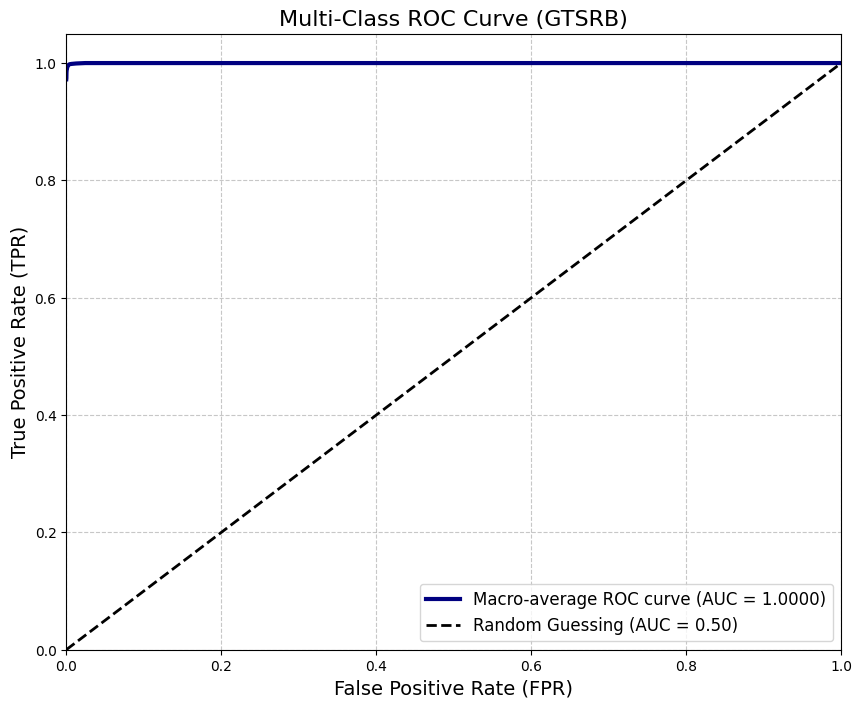

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# 1. Binarize the true labels for One-vs-Rest calculation
n_classes = 43
y_test_binarized = label_binarize(all_labels, classes=range(n_classes))
y_score = np.array(all_probs)

# 2. Calculate the Macro-Average ROC AUC Score
roc_auc_macro = roc_auc_score(all_labels, y_score, multi_class='ovr', average='macro')
print(f"Macro-Average ROC AUC Score: {roc_auc_macro:.4f}")

# 3. Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])

# 4. Compute macro-average ROC curve
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at these points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Finally average it
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr

# 5. Plot the Macro-Average ROC Curve
plt.figure(figsize=(10, 8))
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average ROC curve (AUC = {roc_auc_macro:0.4f})',
         color='navy', linestyle='-', linewidth=3)

# Plot the diagonal line (represents a model guessing randomly)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guessing (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=14)
plt.ylabel('True Positive Rate (TPR)', fontsize=14)
plt.title('Multi-Class ROC Curve (GTSRB)', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Visualize Sample Prediction

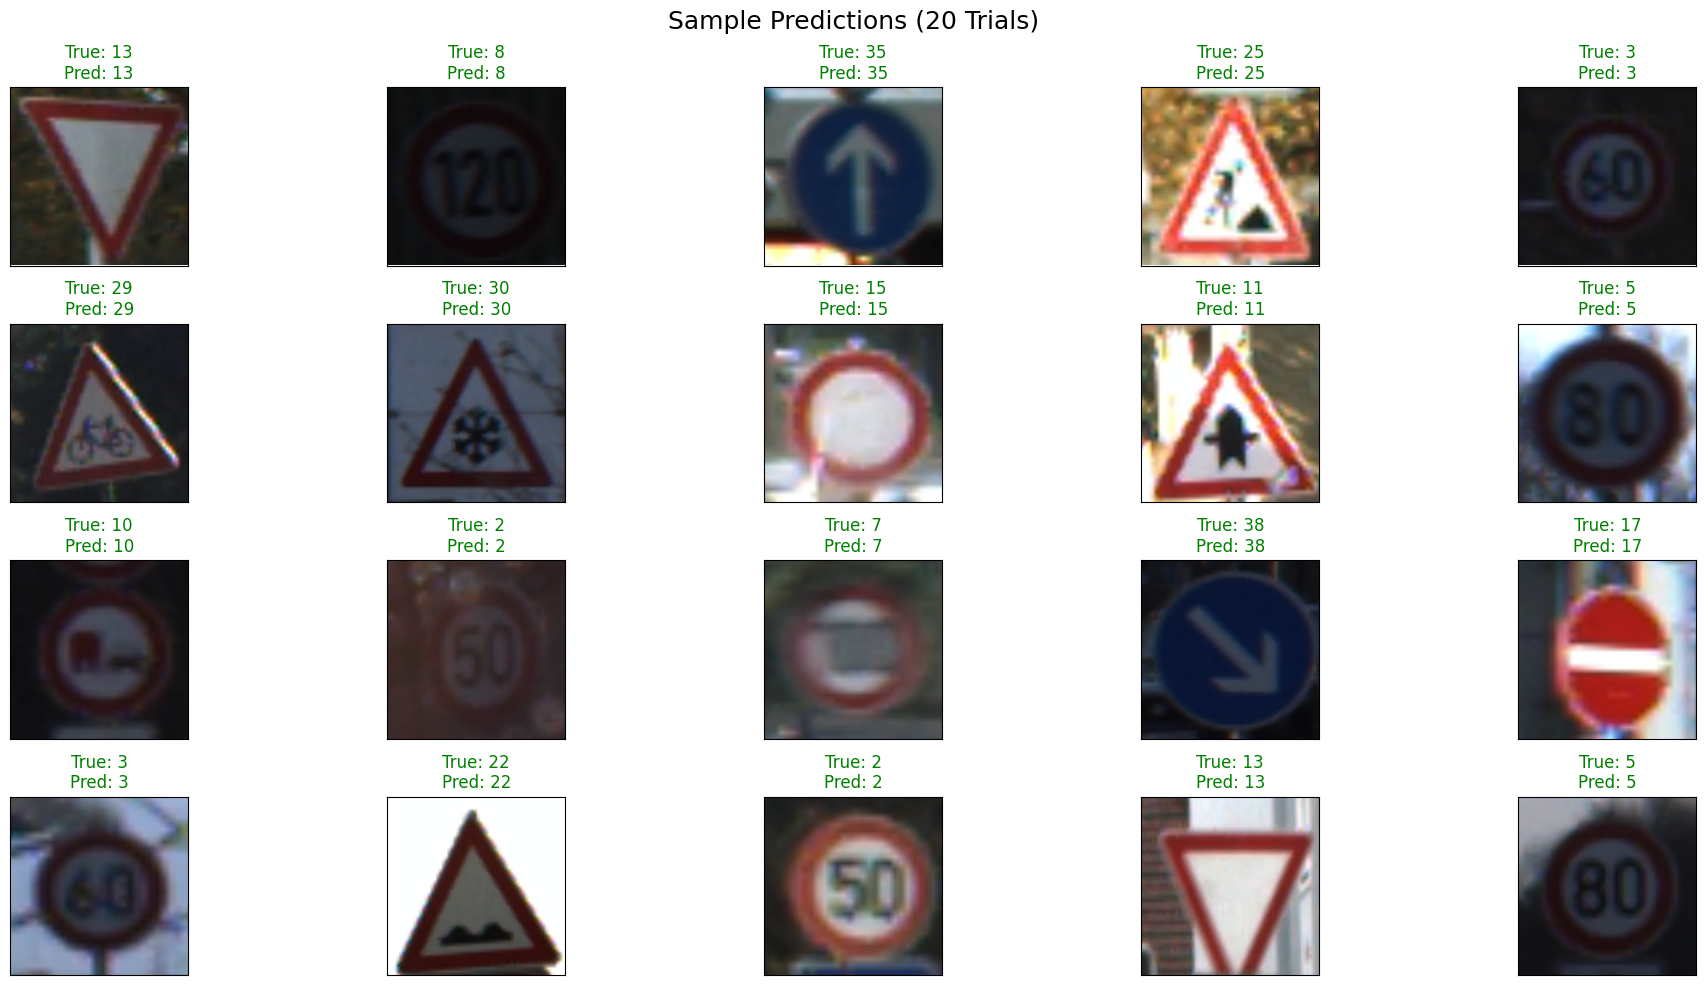

In [27]:
def visualize_sample_predictions(model, dataloader, device, num_images=20):
    model.eval()
    
    # Fetch a single batch of test data
    dataiter = iter(dataloader)
    images, labels = next(dataiter)
    
    # We only need 'num_images' amount of data
    images = images[:num_images]
    labels = labels[:num_images]
    
    # Move to device and predict
    inputs = images.to(device)
    with torch.no_grad():
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
    images = images.cpu()
    preds = preds.cpu()
    
    # Setup plot
    fig = plt.figure(figsize=(20, 10))
    
    # Inverse normalization parameters for viewing
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    for idx in range(num_images):
        ax = fig.add_subplot(4, 5, idx + 1, xticks=[], yticks=[])
        
        # Un-normalize image
        img = images[idx].numpy().transpose((1, 2, 0))
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        ax.imshow(img)
        
        # Check if prediction is correct
        true_label = labels[idx].item()
        pred_label = preds[idx].item()
        color = "green" if true_label == pred_label else "red"
        
        ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=12)
        
    plt.suptitle("Sample Predictions (20 Trials)", fontsize=18)
    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_sample_predictions(model, test_loader, device, num_images=20)

In [28]:
from IPython.display import FileLink
FileLink('alexnet_gtsrb_finetuned.pth')

/kaggle/working/alexnet_gtsrb_finetuned.pth